# Análise Interativa - Desafio 2 (YOLO Segmentação)

**Autor:** Manoel Furtado  
**Objetivo:** Compreender passo a passo a preparação dos dados, divisão do dataset, carregamento, treinamento (opcional) e inferência do modelo YOLO26n de segmentação de fissuras implementados em `solucao_1_yolo_segmentacao.py`.

Este notebook serve como ferramenta de estudo para visualizar:
1. Como o dataset de imagens e labels do Desafio 2 está pareado.
2. Como criar a divisão reprodutível de Treino/Validação/Teste.
3. O código utilizado para disparar o treinamento oficial de 120 épocas.
4. Como ler e sobrepor as anotações originais em formato de polígonos YOLO.
5. Como realizar a inferência utilizando o modelo treinado (`best.pt`) e plotar a segmentação resultante.

## 1. Importações e Configurações

Abaixo importamos as bibliotecas necessárias e garantimos o carregamento de módulos da pasta local de soluções.

In [1]:
import sys
from pathlib import Path

# Adiciona o diretório atual de soluções ao path para importação direta
sys.path.append(str(Path('.').resolve() / 'solucao_1_yolo_segmentacao'))

import cv2
import matplotlib.pyplot as plt
import numpy as np

try:
    from ultralytics import YOLO
    print("Ultralytics YOLO importado com sucesso!")
except ImportError:
    print("ERRO: Ultralytics não instalado. Ative o ambiente conda 'vc_01'.")

DATA_DIR = Path('../data')
print("Caminho dos dados:", DATA_DIR.resolve())

Ultralytics YOLO importado com sucesso!
Caminho dos dados: D:\cursos\BootCamp\Desafio\Desafio\Desafio_2\data


## 2. Verificação de Pares Imagem/Rótulo

O pipeline supervisionado do YOLO requer que cada imagem tenha um arquivo `.txt` correspondente de mesmo nome na pasta `labels` contendo os polígonos. Vamos listar e verificar quantos pares existem.

In [2]:
from solucao_1_yolo_segmentacao import find_pairs

pairs = find_pairs(DATA_DIR)
print(f"Total de pares imagem/label localizados: {len(pairs)}")

if len(pairs) > 0:
    print("\nExemplo de par de arquivos:")
    print("Imagem:", pairs[0][0])
    print("Label :", pairs[0][1])

Total de pares imagem/label localizados: 1551

Exemplo de par de arquivos:
Imagem: ..\data\images\10.rf.f0b182d5a78d6adc75e97f0f2314be9f.jpg
Label : ..\data\labels\10.rf.f0b182d5a78d6adc75e97f0f2314be9f.txt


## 3. Preparação do Dataset (Split)

A função `prepare_dataset` divide os dados reprodutivelmente (usando uma semente/seed fixa). Em vez de duplicar ou mover os arquivos, ela escreve listas com os caminhos absolutos (`train.txt`, `val.txt`, `test.txt`) e cria o arquivo de configuração `data.yaml` do YOLO.

In [3]:
from solucao_1_yolo_segmentacao import parse_args, prepare_dataset

# Simula os argumentos de linha de comando para rodar a preparação
args_prepare = parse_args([
    "--data-dir", str(DATA_DIR),
    "--output-dir", "dataset_yolo_split",
    "--prepare",
    "--val-fraction", "0.15",
    "--test-fraction", "0.10",
    "--seed", "42"
])

data_yaml_path = prepare_dataset(args_prepare)
print(f"\nConfiguração data.yaml gerada com sucesso em: {data_yaml_path.resolve()}")

Pairs: train=1164 val=232 test=155
Created YOLO dataset at dataset_yolo_split

Configuração data.yaml gerada com sucesso em: D:\cursos\BootCamp\Desafio\Desafio\Desafio_2\solucoes\dataset_yolo_split\data.yaml


## 4. Treinamento do Modelo (Opcional)

Abaixo está o bloco contendo a chamada de treinamento oficial em GPU. Por padrão, a variável `execute_training` está definida como `False` para evitar que a execução acidental de todas as células trave o notebook por horas. O treinamento oficial de 120 épocas levou **4 horas e 23 minutos** na GPU GTX 1650 do ambiente.

In [ ]:
# Altere para True apenas se quiser disparar o treinamento oficial
execute_training = False

if execute_training:
    from solucao_1_yolo_segmentacao import train
    
    # Argumentos do treinamento final (120 épocas)
    # Para um sanity check rápido de 3 épocas, mude "--epochs" para "3"
    args_train = parse_args([
        "--data-dir", str(DATA_DIR),
        "--output-dir", "dataset_yolo_split",
        "--train",
        "--model", "../modelos/yolo26n-seg.pt",
        "--epochs", "120",
        "--batch", "4",
        "--imgsz", "640"
    ])
    
    print("Iniciando o treinamento do modelo...")
    train(args_train, Path("dataset_yolo_split/data.yaml"))
else:
    print("Execução de treino desativada por padrão (execute_training = False) para evitar travamento do notebook.")

## 5. Visualização das Anotações Originais de Fissura

Os rótulos do YOLO contêm coordenadas normatizadas (de 0 a 1). Vamos converter esses valores de volta ao tamanho original da imagem para desenhar o polígono de marcação da fissura.

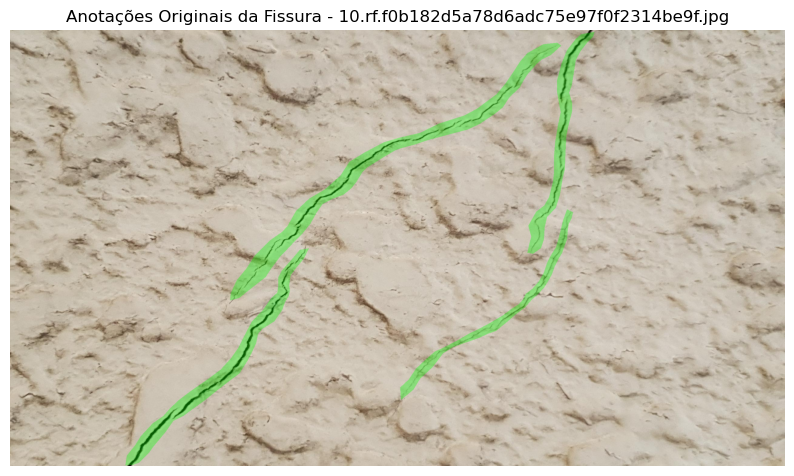

In [4]:
def label_to_polygons(label_path, width, height):
    if not label_path.exists():
        return []
    polygons = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) < 7: # Precisa de pelo menos classe + 3 pontos (6 coordenadas)
            continue
        # O primeiro item é a classe (sempre 0 para fissura), os demais são as coordenadas [x1, y1, x2, y2, ...]
        coords = [float(val) for val in parts[1:]]
        points = []
        for x_norm, y_norm in zip(coords[0::2], coords[1::2]):
            x = int(round(x_norm * (width - 1)))
            y = int(round(y_norm * (height - 1)))
            points.append([x, y])
        if len(points) >= 3:
            polygons.append(np.array(points, dtype=np.int32))
    return polygons

# Carrega e exibe a primeira imagem com sua anotação original
img_path, label_path = pairs[0]
image = cv2.imread(str(img_path))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape

polygons = label_to_polygons(label_path, w, h)
overlay_image = image_rgb.copy()
cv2.fillPoly(overlay_image, polygons, (0, 255, 0)) # Polígono verde
visual_image = cv2.addWeighted(image_rgb, 0.65, overlay_image, 0.35, 0)

plt.figure(figsize=(10, 8))
plt.imshow(visual_image)
plt.title(f"Anotações Originais da Fissura - {img_path.name}")
plt.axis("off")
plt.show()

## 6. Carregamento do Modelo YOLO

Vamos carregar o modelo YOLO de segmentação. Se o modelo final treinado no projeto (`best.pt`) já existir, nós o usaremos. Caso contrário, carregaremos os pesos padrão do baseline (`yolo26n-seg.pt`).

In [5]:
trained_weights = Path("dataset_yolo_split/runs/fissuras_yolo_seg/weights/best.pt")
base_weights = Path("../modelos/yolo26n-seg.pt")

weights_path = trained_weights if trained_weights.exists() else base_weights
print(f"Carregando pesos de: {weights_path.resolve()}")

model = YOLO(str(weights_path))
print("Modelo carregado com sucesso!")

Carregando pesos de: D:\cursos\BootCamp\Desafio\Desafio\Desafio_2\solucoes\dataset_yolo_split\runs\fissuras_yolo_seg\weights\best.pt
Modelo carregado com sucesso!


## 7. Inferência Interativa em Imagens de Teste

Vamos carregar uma imagem do split de teste e executar a predição do modelo YOLO.

Imagem de teste selecionada: 2144.rf.47067d6442def08fd292cd710a68e1f3.jpg


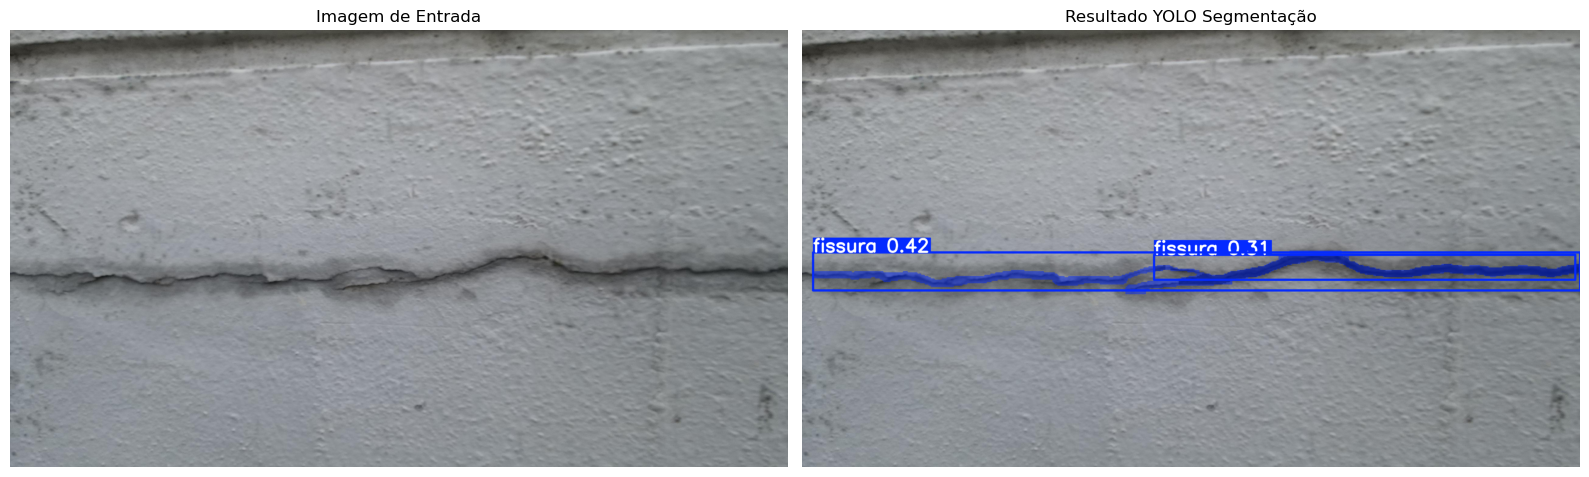

In [6]:
# Tenta ler a primeira imagem listada em test.txt
test_txt = Path("dataset_yolo_split/test.txt")
if test_txt.exists():
    test_lines = test_txt.read_text(encoding="utf-8").splitlines()
    sample_path = Path(test_lines[0].strip())
else:
    # Fallback para o primeiro par
    sample_path = pairs[0][0]

print("Imagem de teste selecionada:", sample_path.name)

# Executa inferência do YOLO
results = model.predict(source=str(sample_path), conf=0.25, imgsz=640, verbose=False)
result = results[0]

# Converte o resultado visual com caixas/máscaras gerado pelo YOLO
yolo_rendered = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
original_rgb = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)

# Exibe original vs predição
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(original_rgb)
axes[0].set_title("Imagem de Entrada")
axes[0].axis("off")

axes[1].imshow(yolo_rendered)
axes[1].set_title("Resultado YOLO Segmentação")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 8. Inspeção Quantitativa da Máscara YOLO

Aqui podemos acessar a máscara de pixels (formato binário) predita e medir a porcentagem de área do concreto afetada pela fissura.

In [7]:
if result.masks is not None:
    print(f"Quantidade de fissuras/instâncias detectadas: {len(result.masks)}")
    
    # Pegamos a primeira máscara predita (geralmente em formato 0 ou 1)
    first_mask = result.masks.data[0].cpu().numpy()
    
    # Porcentagem de pixels pretos (defeito) vs total da imagem
    defect_pixels = np.sum(first_mask > 0)
    total_pixels = first_mask.size
    defect_ratio = (defect_pixels / total_pixels) * 100
    
    print(f"Dimensão da máscara da rede: {first_mask.shape}")
    print(f"Percentual de área ocupada pela fissura: {defect_ratio:.3f}%")
else:
    print("Nenhuma fissura acima do limiar de confiança detectada pelo modelo nesta imagem.")

Quantidade de fissuras/instâncias detectadas: 2
Dimensão da máscara da rede: (384, 640)
Percentual de área ocupada pela fissura: 1.949%


## 9. Considerações e Exportação

O modelo YOLO26n-seg foi projetado para alta eficiência. Se você quiser testar a exportação do modelo treinado para formatos compatíveis com celulares/edge (como ONNX), descomente e execute a célula abaixo:

```python
# model.export(format="onnx", imgsz=640)
```